In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

# Dataset Description: Netflix Movies and TV Shows

This dataset comes from Kaggle and contains information about movies and TV shows available on Netflix as of 2021. The data was originally scraped from the public Netflix catalog using a web-scraping script created by the dataset author. Each row represents a single title, and the dataset includes metadata such as as title, director, cast, country of origin, release year, rating, duration, genres, and a short description.

The dataset contains 8,807 titles, including both movies and TV shows. Most features are categorical, such as rating, country, and genre, while release_year is numeric. Several fields contain missing values, especially director, cast, and country, which is expected because Netflix does not always list this information for TV shows.

This dataset is interesting because it allows us to explore trends in Netflix's catalog, such as the distribution of movies vs. TV shows, the most common genres, how content has changed over time, and how ratings vary across titles.

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## Question 1 - How many Movies vs. TV Shows are on Netflix?

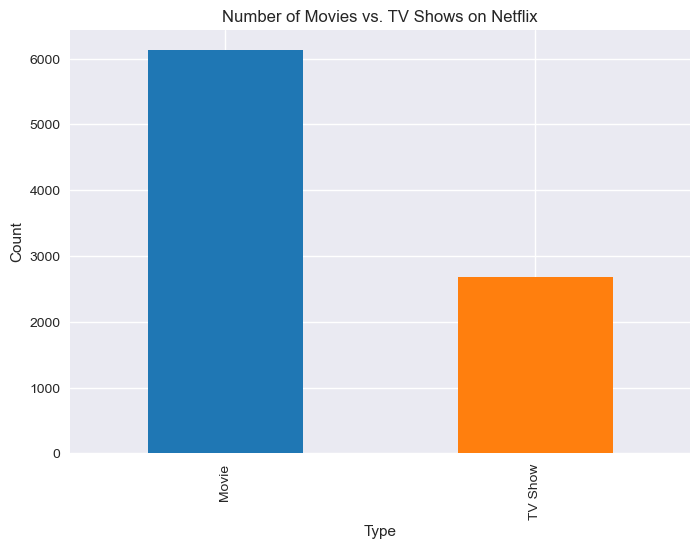

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [5]:
type_counts = df['type'].value_counts()

type_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Number of Movies vs. TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

type_counts

### Answer:
Netflix has significantly more Movies(6,131) than TV Shows(2,676) in the catalog. This means the platform's library is heavily movie-dominant, with movies making up roughly 70% of all titles.

## Question 2 - What are the most common ratings on Netflix?

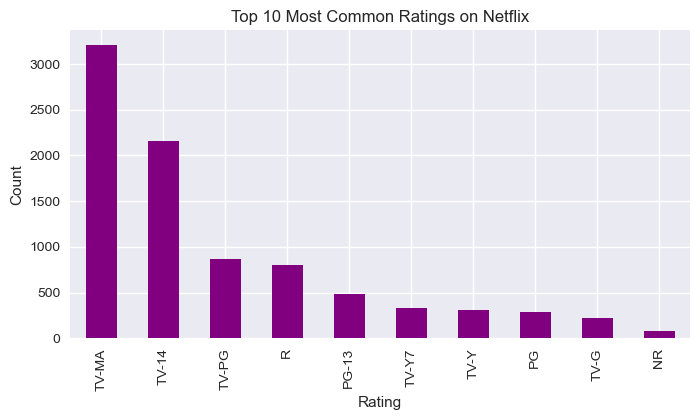

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [6]:
rating_counts = df['rating'].value_counts().head(10)

rating_counts.plot(kind='bar', figsize=(8,4), color='purple')
plt.title('Top 10 Most Common Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

rating_counts

### Answer:
The most common rating on Netflix is TV-MA, followed by TV-14 and TV-PG. This shows that Netflix's catalog leans heavily toward mature content, with a large portion of titles intented for adult audiences.

## Question 3 - How has Netflix content changed over time?

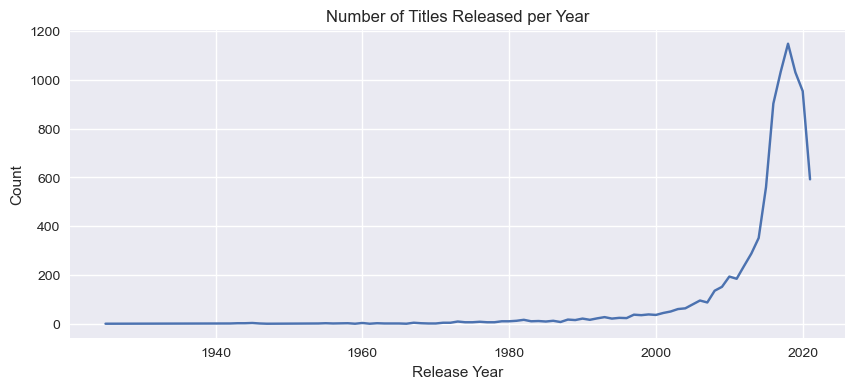

release_year
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

In [7]:
titles_per_year = df['release_year'].value_counts().sort_index()

titles_per_year.plot(figsize=(10,4))
plt.title('Number of Titles Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

titles_per_year.tail()

### Answer:
Netflix's catalog is dominated by recent releases, especially from 2015-2021. The number of titles increases sharply in the 2010s, reflecting Netflix's rapid expansion and the global rise of streaming platforms.

## Question 5 - Which countries produce the most Netflix content

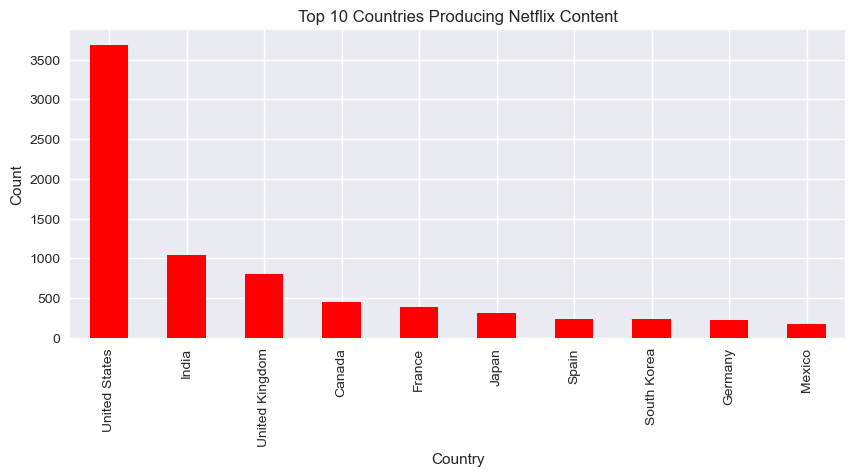

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

In [8]:
country_counts = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

country_counts.plot(kind='bar', figsize=(10,4), color='red')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

country_counts

### Answer:
The United States produces the most Netflix content by a large margin, followed by India, the United Kingdom, Canada, France, and Japan. This reflects Netflix's strong presence in North America and its growing investment in international markets.